# Logistic Regression

Logistic Regression is a **supervised machine learning algorithm used for classification problems**.

Unlike Linear Regression, which predicts continuous values, Logistic Regression predicts **probabilities of class membership**.

Common applications include:

- Email spam detection
- Disease prediction
- Credit risk analysis
- Customer churn prediction

In this notebook we will learn:

1. What Logistic Regression is
2. The mathematical intuition
3. Sigmoid function
4. Model training using Scikit-Learn
5. Model evaluation
6. Visualization of decision boundary

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Logistic Regression Concept

Logistic Regression predicts the probability that a data point belongs to a class.

Instead of predicting a value directly, the model predicts a **probability between 0 and 1**.

If the probability is:

- greater than **0.5 → Class 1**
- less than **0.5 → Class 0**

To convert linear output into probability, Logistic Regression uses the **Sigmoid Function**.

## Sigmoid Function

The sigmoid function converts any real value into a number between **0 and 1**.

Formula:

p = 1 / (1 + e^(-z))

Where:

z = b0 + b1x1 + b2x2 + ... + bnxn

The output represents the **probability of belonging to class 1**.

## Plot the Sigmoid Curve

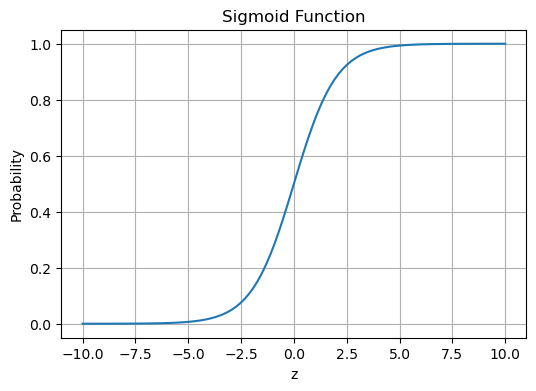

In [12]:
x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))

plt.figure(figsize=(6,4))
plt.plot(x, y)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Probability")
plt.grid(True)
plt.show()

## Example Dataset

In [13]:
data = pd.DataFrame({
    "Hours_Studied": [1,2,3,4,5,6,7,8],
    "Pass": [0,0,0,0,1,1,1,1]
})

data

,Hours_Studied,Pass
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1


## Data Visualization

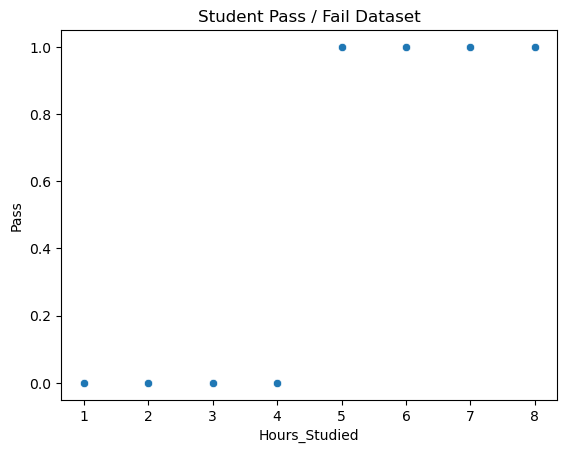

In [14]:
sns.scatterplot(x="Hours_Studied", y="Pass", data=data)
plt.title("Student Pass / Fail Dataset")
plt.show()

## Define Features and Target

In machine learning, the dataset is separated into:

**Features (X)**  
The input variables used to make predictions.

**Target (y)**  
The output variable that the model tries to predict.

In this example:

- **Hours_Studied** → Feature  
- **Pass** → Target variable

In [15]:
X = data[["Hours_Studied"]]
y = data["Pass"]

## Train the Logistic Regression Model

Now we create and train the Logistic Regression model using **Scikit-Learn**.

The training process allows the model to learn the relationship between the feature (**Hours_Studied**) and the target (**Pass/Fail**).

In [16]:
model = LogisticRegression()

model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Make Predictions

After training the model, we can use it to predict the class labels for the input data.

The model will output either:

- **0 → Fail**
- **1 → Pass**

In [17]:
predictions = model.predict(X)

predictions

array([0, 0, 0, 0, 1, 1, 1, 1])

## Predict Probabilities

Logistic Regression does not directly predict classes first.  
Instead, it calculates the **probability that a sample belongs to each class**.

`predict_proba()` returns two probabilities:

- Probability of **Class 0**
- Probability of **Class 1**

In [18]:
probabilities = model.predict_proba(X)

probabilities

array([[0.98360598, 0.01639402],
       [0.9490448 , 0.0509552 ],
       [0.85254586, 0.14745414],
       [0.64219651, 0.35780349],
       [0.35780843, 0.64219157],
       [0.14745684, 0.85254316],
       [0.05095624, 0.94904376],
       [0.01639437, 0.98360563]])

## Model Accuracy

Accuracy measures how many predictions were correct.

Accuracy is calculated as:

Accuracy = Correct Predictions / Total Predictions

In [19]:
accuracy = accuracy_score(y, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


## Confusion Matrix

A confusion matrix helps us understand how well the model performed.

It shows:

- **True Positives**
- **True Negatives**
- **False Positives**
- **False Negatives**

This helps evaluate classification performance in more detail.

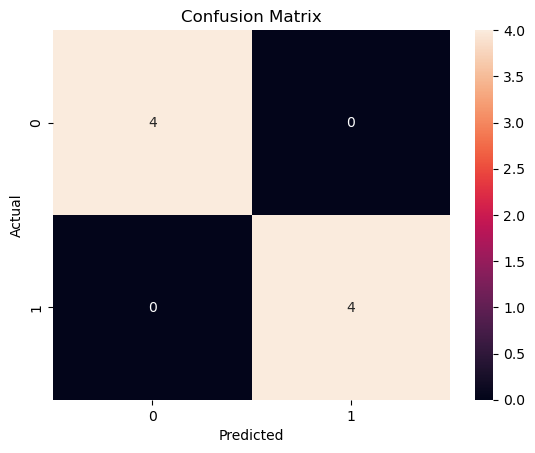

In [20]:
cm = confusion_matrix(y, predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

The classification report provides several important metrics:

- **Precision** – how many predicted positives are correct
- **Recall** – how many actual positives were correctly predicted
- **F1 Score** – balance between precision and recall

In [21]:
print(classification_report(y, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



## Classification Report Explanation

The classification report provides several important metrics to evaluate the performance of a classification model.

The report includes the following metrics:

### Precision

Precision measures how many of the predicted positive values were actually correct.

Precision is calculated as:

Precision = True Positives / (True Positives + False Positives)

In this report:

- Class **0 precision = 1.00**
- Class **1 precision = 1.00**

This means that every prediction made by the model for both classes was correct.

---

### Recall

Recall measures how many of the actual positive samples were correctly identified by the model.

Recall is calculated as:

Recall = True Positives / (True Positives + False Negatives)

In this report:

- Class **0 recall = 1.00**
- Class **1 recall = 1.00**

This means the model successfully identified all actual samples for both classes.

---

### F1-Score

The F1-score is the harmonic mean of precision and recall. It balances both metrics and is useful when evaluating classification models.

F1-score = 2 × (Precision × Recall) / (Precision + Recall)

In this report:

- Class **0 F1-score = 1.00**
- Class **1 F1-score = 1.00**

This indicates perfect classification performance.

---

### Support

Support represents the number of actual samples in each class.

- Class **0 → 4 samples**
- Class **1 → 4 samples**

Total samples in the dataset = **8**

---

### Accuracy

Accuracy measures the overall correctness of the model.

Accuracy = Correct Predictions / Total Predictions

Here:

Accuracy = 8 / 8 = **1.00 (100%)**

This means the model predicted all samples correctly.

---

### Macro Average

Macro average calculates the average of precision, recall, and F1-score across all classes **without considering class imbalance**.

Macro Avg = Average of metrics for each class

Here all values are **1.00**, indicating perfect performance.

---

### Weighted Average

Weighted average also calculates the average of precision, recall, and F1-score, but **takes the number of samples in each class into account**.

Since both classes contain the same number of samples, the weighted average is also **1.00**.

---

### Final Interpretation

The classification report shows that the Logistic Regression model perfectly classified all samples in the dataset.

However, this result occurs because the dataset is **very small and perfectly separable**. In real-world datasets, models usually produce some classification errors.

## Logistic Regression with Multiple Variables

Logistic Regression is not limited to a single feature.  
It can use **multiple input variables** to make predictions.

The logistic regression model with multiple features is written as:

z = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ

Where:

- b₀ → intercept
- b₁, b₂, ... bₙ → coefficients
- x₁, x₂, ... xₙ → input features

The value **z** is then passed through the **sigmoid function** to calculate the probability.

p = 1 / (1 + e⁻ᶻ)

This probability is then used to classify the sample into a class.

For example, to predict whether a student passes an exam, we might use multiple variables such as:

- Hours studied
- Attendance
- Assignment marks
- Previous GPA

Using multiple features often improves the predictive power of the model.